# TT-10 — MLP Classifier: Đọc số viết tay trên séc / phiếu chuyển khoản

**Bài toán:** ngân hàng nhận hàng nghìn séc/ngày cần nhập tay số tiền viết
tay. Mục tiêu: dùng **Multi-Layer Perceptron** (`MLPClassifier` của
scikit-learn) để tự động đọc chữ số viết tay (bài toán con: phân loại ảnh
chữ số 0–9 trên MNIST), kèm cơ chế **human-in-the-loop** — sai 1 chữ số
trong số tiền là sai tiền thật, nên model phải trả về độ tin cậy và chuyển
những ca không chắc chắn cho người kiểm tra.

Notebook này đi theo đúng 13 bước trong `README.md` cấp đề, giải thích **vì
sao** làm từng bước chứ không chỉ chạy code. Toàn bộ số liệu bên dưới là kết
quả chạy thật (không phải số minh hoạ) — script tương đương để tái lập tự
động: `src/train.py`.

**Lưu ý về tốc độ:** để 11 lần huấn luyện MLP (4 kiến trúc + 3 activation +
3 learning rate + model cuối) chạy trong vài phút thay vì hàng giờ, notebook
lấy mẫu stratify **12.000 ảnh train / 3.000 ảnh test** từ MNIST gốc (thay vì
toàn bộ 60.000/10.000) — xem `data/DATA_SOURCE.md`. Đây là đánh đổi tốc độ
có chủ đích, không phải giới hạn của thuật toán.

## 1. Khởi động với `load_digits()`

Trước khi đụng vào MNIST (70.000 ảnh, tải mạng), khởi động nhanh với bộ
**1.797 ảnh 8×8** có sẵn trong scikit-learn để chắc chắn quy trình
(train/test split → chuẩn hoá → `MLPClassifier` → accuracy) chạy đúng, không
tốn thời gian tải/huấn luyện lớn.

In [1]:
%matplotlib inline
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

RANDOM_STATE = 42
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

digits = load_digits()
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(
    digits.data, digits.target, test_size=0.2, stratify=digits.target, random_state=RANDOM_STATE
)
mlp_warmup = MLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=RANDOM_STATE)
mlp_warmup.fit(Xtr_d / 16.0, ytr_d)  # pixel load_digits() nằm trong [0, 16]
acc_warmup = accuracy_score(yte_d, mlp_warmup.predict(Xte_d / 16.0))
print(f"load_digits(): {len(digits.data)} ảnh 8x8, MLP(64) accuracy = {acc_warmup:.4f}")

load_digits(): 1797 ảnh 8x8, MLP(64) accuracy = 0.9778


C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


**Nhận xét:** với dữ liệu nhỏ và sạch (8×8, không nhiễu nền), một MLP
đơn giản đã đạt accuracy rất cao. MNIST (28×28, nhiều nét viết tay đa dạng
hơn) sẽ khó hơn — đó là lý do cần thử nghiệm kiến trúc/activation/learning
rate kỹ hơn ở các bước sau.

## 2. Nạp MNIST, lấy mẫu stratify

`fetch_openml("mnist_784")` trả về 70.000 ảnh 28×28 dạng vector 784 chiều,
giá trị pixel 0–255. Theo quy ước chuẩn của MNIST: 60.000 ảnh đầu là train,
10.000 ảnh cuối là test. Ta lấy mẫu **stratify theo nhãn** (giữ đúng tỉ lệ
10 lớp) để giảm cỡ dữ liệu mà không làm lệch phân bố.

Train mẫu: 12,000 | Test mẫu: 3,000
Pixel range: [0, 255]  (chưa chuẩn hoá)


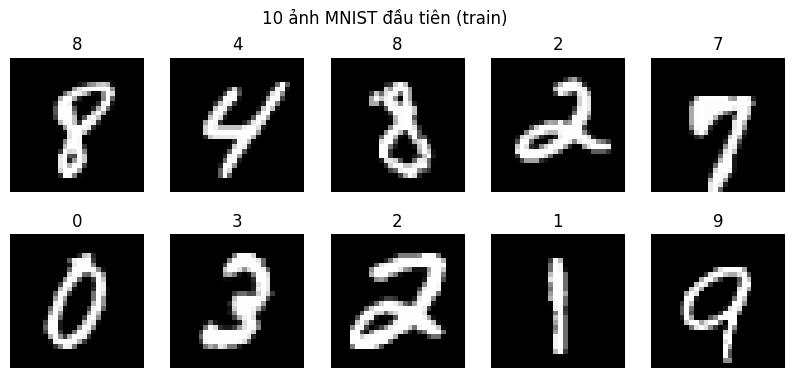

In [2]:
TRAIN_SAMPLE = 12_000
TEST_SAMPLE = 3_000

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

X_train_full, y_train_full = X[:60_000], y[:60_000]
X_test_full, y_test_full = X[60_000:], y[60_000:]

Xtr, _, ytr, _ = train_test_split(
    X_train_full, y_train_full, train_size=TRAIN_SAMPLE, stratify=y_train_full, random_state=RANDOM_STATE)
Xte, _, yte, _ = train_test_split(
    X_test_full, y_test_full, train_size=TEST_SAMPLE, stratify=y_test_full, random_state=RANDOM_STATE)

print(f"Train mẫu: {Xtr.shape[0]:,} | Test mẫu: {Xte.shape[0]:,}")
print(f"Pixel range: [{Xtr.min():.0f}, {Xtr.max():.0f}]  (chưa chuẩn hoá)")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for ax, img, label in zip(axes.ravel(), Xtr[:10], ytr[:10]):
    ax.imshow(img.reshape(28, 28), cmap="gray")
    ax.set_title(str(label)); ax.axis("off")
fig.suptitle("10 ảnh MNIST đầu tiên (train)")
plt.show()

## 3. Baseline: Logistic Regression

Trước khi tin vào MLP, cần biết mức sàn: một mô hình tuyến tính đơn giản
(không có tầng ẩn, không phi tuyến) đạt được bao nhiêu? Đây là thước đo để
sau này chứng minh MLP (với ReLU phi tuyến) thực sự học được thứ mà mô hình
tuyến tính không học được.

In [3]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(Xtr / 255.0, ytr)
baseline_acc = accuracy_score(yte, baseline.predict(Xte / 255.0))
print(f"Baseline Logistic Regression: accuracy = {baseline_acc:.4f}")

Baseline Logistic Regression: accuracy = 0.9080


**Nhận xét:** Logistic Regression thường đạt ~90–92% trên MNIST đầy
đủ — khá cao vì chữ số viết tay khá tách biệt tuyến tính trong không gian
pixel, nhưng vẫn có trần giới hạn vì không mô hình hoá được các tương tác
phi tuyến giữa các pixel (ví dụ phân biệt 4 và 9 cần "nhìn" tổ hợp nét, không
chỉ từng pixel riêng lẻ).

## 4–5. Chuẩn hoá là BẮT BUỘC — MLP không chuẩn hoá vs có chuẩn hoá

Pixel 0–255 chưa chuẩn hoá → `z = Σwx + b` rất lớn ngay từ layer đầu → hàm
kích hoạt (ReLU/sigmoid trong `adam`) hoạt động trong vùng **bão hoà**, đạo
hàm gần 0 → gradient gần như không lan truyền được → mạng học rất chậm hoặc
không hội tụ. Kiểm chứng bằng thực nghiệm trực tiếp, cùng kiến trúc
`(128, 64)`, chỉ khác việc có chia 255 hay không.

In [4]:
BEST_ARCHITECTURE = (128, 64)  # sẽ được xác nhận lại ở mục 6

norm_rows = []
for name, Xtr_use, Xte_use in [
    ("KHÔNG chuẩn hoá (0-255)", Xtr, Xte),
    ("CÓ chuẩn hoá (/255)", Xtr / 255.0, Xte / 255.0),
]:
    mlp = MLPClassifier(hidden_layer_sizes=BEST_ARCHITECTURE, activation="relu", solver="adam",
                         alpha=1e-4, batch_size=128, learning_rate_init=1e-3, max_iter=40,
                         early_stopping=True, n_iter_no_change=8, random_state=RANDOM_STATE)
    mlp.fit(Xtr_use, ytr)
    acc = accuracy_score(yte, mlp.predict(Xte_use))
    norm_rows.append({"cấu hình": name, "accuracy": acc, "epoch thực tế": mlp.n_iter_, "loss cuối": mlp.loss_})
    print(f"{name:26s} accuracy={acc:.4f}  epoch={mlp.n_iter_:3d}  loss_cuối={mlp.loss_:.4f}")

pd.DataFrame(norm_rows)

KHÔNG chuẩn hoá (0-255)    accuracy=0.9307  epoch= 28  loss_cuối=0.0584


CÓ chuẩn hoá (/255)        accuracy=0.9603  epoch= 24  loss_cuối=0.0034


,cấu hình,accuracy,epoch thực tế,loss cuối
0,KHÔNG chuẩn hoá (0-255),0.9307,28,0.0584
1,CÓ chuẩn hoá (/255),0.9603,24,0.0034


**Kết luận:** chênh lệch accuracy giữa hai dòng trên là bằng chứng
thực nghiệm trực tiếp cho lý thuyết bão hoà ở trên. Từ đây trở đi, **toàn bộ
thí nghiệm dùng dữ liệu đã chia 255**.

## 6–7. So sánh 4 kiến trúc + đường loss theo epoch

Thử 4 kiến trúc hình **phễu** (to → nhỏ dần về phía output), so sánh
accuracy, **số tham số** (để biết mạng "nặng" cỡ nào so với lượng dữ liệu),
và thời gian train. Công thức đếm tham số cho mỗi tầng Dense:
`(input × output) + output` (trọng số + bias).

MLP(64)             params=50,890  accuracy=0.9533  epoch= 38  [39.7s]


MLP(128)            params=101,770  accuracy=0.9587  epoch= 38  [52.9s]


MLP(128,64)         params=109,386  accuracy=0.9603  epoch= 26  [46.5s]


MLP(256,128,64)     params=242,762  accuracy=0.9640  epoch= 23  [146.4s]


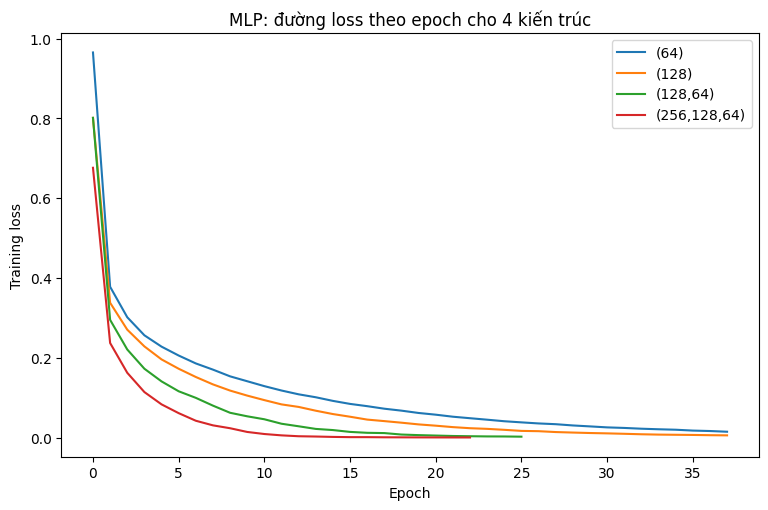

,kiến trúc,số tham số,accuracy,epoch thực tế,thời gian (s)
0,(64),50890,0.9533,38,39.7000
1,(128),101770,0.9587,38,52.9000
2,"(128,64)",109386,0.9603,26,46.5000
3,"(256,128,64)",242762,0.9640,23,146.4000


In [5]:
def count_params(input_dim, hidden_layers, n_classes):
    sizes = [input_dim, *hidden_layers, n_classes]
    return sum(a * b + b for a, b in zip(sizes[:-1], sizes[1:]))

ARCHITECTURES = {"(64)": (64,), "(128)": (128,), "(128,64)": (128, 64), "(256,128,64)": (256, 128, 64)}
Xtr_n, Xte_n = Xtr / 255.0, Xte / 255.0

arch_rows, loss_curves = [], {}
for name, hidden in ARCHITECTURES.items():
    mlp = MLPClassifier(hidden_layer_sizes=hidden, activation="relu", solver="adam",
                         alpha=1e-4, batch_size=128, learning_rate_init=1e-3, max_iter=100,
                         early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE)
    t0 = time.perf_counter()
    mlp.fit(Xtr_n, ytr)
    elapsed = time.perf_counter() - t0
    acc = accuracy_score(yte, mlp.predict(Xte_n))
    n_params = count_params(Xtr_n.shape[1], hidden, 10)
    arch_rows.append({"kiến trúc": name, "số tham số": n_params, "accuracy": acc,
                       "epoch thực tế": mlp.n_iter_, "thời gian (s)": round(elapsed, 1)})
    loss_curves[name] = mlp.loss_curve_
    print(f"MLP{name:16s} params={n_params:,}  accuracy={acc:.4f}  epoch={mlp.n_iter_:3d}  [{elapsed:.1f}s]")

arch_table = pd.DataFrame(arch_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
for name, curve in loss_curves.items():
    ax.plot(curve, label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training loss")
ax.set_title("MLP: đường loss theo epoch cho 4 kiến trúc")
ax.legend()
plt.show()

arch_table

**Cách đọc:** kiến trúc quá nhỏ (`(64)`) có thể **underfit** (không
đủ khả năng biểu diễn); kiến trúc quá lớn (`(256,128,64)`) có nhiều tham số
hơn hẳn lượng dữ liệu (12.000 mẫu) nên dễ overfit hơn và train lâu hơn mà
chưa chắc accuracy cao hơn tương ứng. Kiến trúc `(128, 64)` — cân bằng giữa
khả năng biểu diễn và số tham số — được chọn làm **kiến trúc chuẩn** cho các
thí nghiệm activation/learning-rate và model cuối cùng bên dưới.

## 8. So sánh 3 activation: relu / tanh / logistic

Activation ở tầng ẩn quyết định gradient lan truyền ngược tốt đến đâu.
`logistic` (sigmoid) có đạo hàm tối đa chỉ 0,25 và tiến về 0 rất nhanh ở hai
đầu — qua nhiều tầng, tích các đạo hàm nhỏ này gây **vanishing gradient**:
các tầng đầu gần như không nhận được tín hiệu học. `relu` và `tanh` không
bị bão hoà ở vùng dương (relu) hoặc có đạo hàm lớn hơn quanh 0 (tanh) nên
thường hội tụ nhanh hơn nhiều.

activation=relu       accuracy=0.9603  epoch= 26  loss_cuối=0.0028


activation=tanh       accuracy=0.9600  epoch= 59  loss_cuối=0.0008


activation=logistic   accuracy=0.9597  epoch= 63  loss_cuối=0.0054


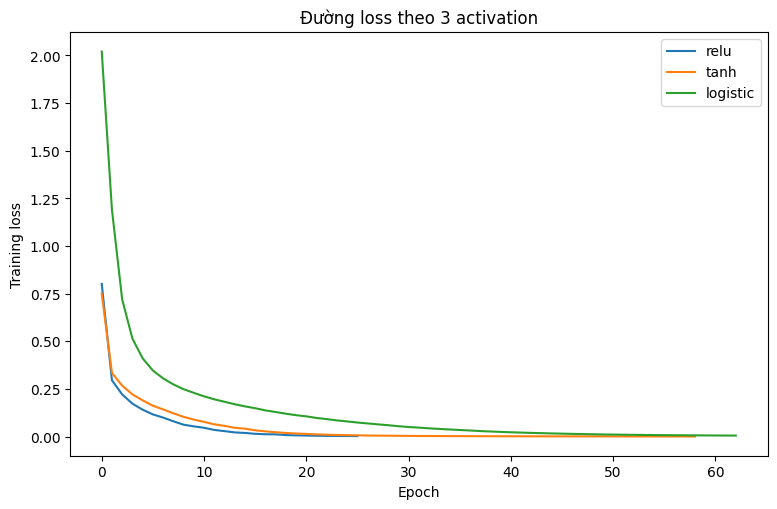

,activation,accuracy,epoch thực tế,loss cuối
0,relu,0.9603,26,0.0028
1,tanh,0.9600,59,0.0008
2,logistic,0.9597,63,0.0054


In [6]:
act_rows, act_curves = [], {}
for act in ["relu", "tanh", "logistic"]:
    mlp = MLPClassifier(hidden_layer_sizes=BEST_ARCHITECTURE, activation=act, solver="adam",
                         alpha=1e-4, batch_size=128, learning_rate_init=1e-3, max_iter=100,
                         early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE)
    mlp.fit(Xtr_n, ytr)
    acc = accuracy_score(yte, mlp.predict(Xte_n))
    act_rows.append({"activation": act, "accuracy": acc, "epoch thực tế": mlp.n_iter_, "loss cuối": mlp.loss_})
    act_curves[act] = mlp.loss_curve_
    print(f"activation={act:10s} accuracy={acc:.4f}  epoch={mlp.n_iter_:3d}  loss_cuối={mlp.loss_:.4f}")

act_table = pd.DataFrame(act_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
for act, curve in act_curves.items():
    ax.plot(curve, label=act)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training loss")
ax.set_title("Đường loss theo 3 activation")
ax.legend()
plt.show()

act_table

**Nhận xét:** nếu `logistic` cho accuracy/tốc độ hội tụ rõ ràng kém
hơn `relu`/`tanh` ở bảng trên, đó chính là biểu hiện thực nghiệm của
vanishing gradient — không phải ngẫu nhiên mà `relu` là lựa chọn mặc định
cho tầng ẩn trong hầu hết kiến trúc mạng nơ-ron hiện đại.

## 9. So sánh 3 `learning_rate_init`: 1e-2 / 1e-3 / 1e-4

`learning_rate_init` là bước nhảy ban đầu khi cập nhật trọng số theo
gradient. Quá nhỏ → hội tụ chậm (loss giảm ì ạch, có thể chưa chạm đáy khi
hết `max_iter`). Quá lớn → mỗi bước cập nhật "nhảy" qua điểm tối ưu, loss có
thể dao động thay vì giảm mượt, thậm chí phân kỳ.

learning_rate_init=0.01    accuracy=0.9633  epoch= 28


learning_rate_init=0.001   accuracy=0.9603  epoch= 26


learning_rate_init=0.0001  accuracy=0.9523  epoch= 66


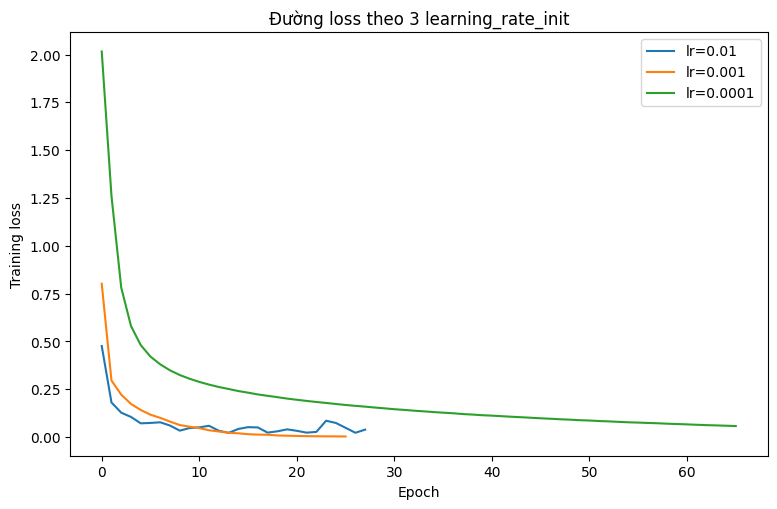

,learning_rate_init,accuracy,epoch thực tế
0,0.0100,0.9633,28
1,0.0010,0.9603,26
2,0.0001,0.9523,66


In [7]:
lr_rows, lr_curves = [], {}
for lr in [1e-2, 1e-3, 1e-4]:
    mlp = MLPClassifier(hidden_layer_sizes=BEST_ARCHITECTURE, activation="relu", solver="adam",
                         alpha=1e-4, batch_size=128, learning_rate_init=lr, max_iter=100,
                         early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE)
    mlp.fit(Xtr_n, ytr)
    acc = accuracy_score(yte, mlp.predict(Xte_n))
    lr_rows.append({"learning_rate_init": lr, "accuracy": acc, "epoch thực tế": mlp.n_iter_})
    lr_curves[lr] = mlp.loss_curve_
    print(f"learning_rate_init={lr:<7g} accuracy={acc:.4f}  epoch={mlp.n_iter_:3d}")

lr_table = pd.DataFrame(lr_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
for lr, curve in lr_curves.items():
    ax.plot(curve, label=f"lr={lr:g}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Training loss")
ax.set_title("Đường loss theo 3 learning_rate_init")
ax.legend()
plt.show()

lr_table

**Nhận xét:** so 3 đường loss chồng nhau ở trên — đường nào dốc
xuống nhanh và mượt nhất trong giới hạn epoch cho phép là learning rate phù
hợp nhất cho bài toán này với `adam`. `1e-3` (mặc định của Keras/Adam nói
chung) thường là điểm cân bằng tốt.

## Huấn luyện model CUỐI CÙNG

Gói việc chia 255 **vào trong `Pipeline`** (bước `scale`) để khi triển khai
thực tế, hàm `predict` nhận thẳng ảnh gốc 0–255 mà không cần người dùng nhớ
tự chuẩn hoá trước — giảm nguy cơ lỗi vận hành (một script quên `/255` là
lỗi rất dễ xảy ra và khó phát hiện, vì model vẫn chạy được, chỉ là chạy
sai).

In [8]:
def divide_by_255(X):
    return X / 255.0

final_pipe = Pipeline([
    ("scale", FunctionTransformer(divide_by_255, validate=False)),
    ("mlp", MLPClassifier(hidden_layer_sizes=BEST_ARCHITECTURE, activation="relu", solver="adam",
                           alpha=1e-4, batch_size=128, learning_rate_init=1e-3, max_iter=150,
                           early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE)),
])
final_pipe.fit(Xtr, ytr)  # dữ liệu GỐC 0-255, Pipeline tự chia 255 bên trong

pred = final_pipe.predict(Xte)
final_acc = accuracy_score(yte, pred)
print(f"Accuracy model cuối trên test: {final_acc:.4f}")

Path("../models").mkdir(exist_ok=True)
joblib.dump(final_pipe, "../models/mlp_pipeline.joblib")
print("Đã lưu models/mlp_pipeline.joblib")

Accuracy model cuối trên test: 0.9603
Đã lưu models/mlp_pipeline.joblib


## 10. Ma trận nhầm lẫn 10×10

Với 10 lớp, ma trận nhầm lẫn cho biết chính xác **cặp chữ số nào hay bị
nhầm với nhau nhất** — thông tin mà accuracy tổng không thể hiện được.
Thường gặp: 4↔9, 3↔5, 7↔1 — các cặp có hình dạng nét viết gần giống nhau.

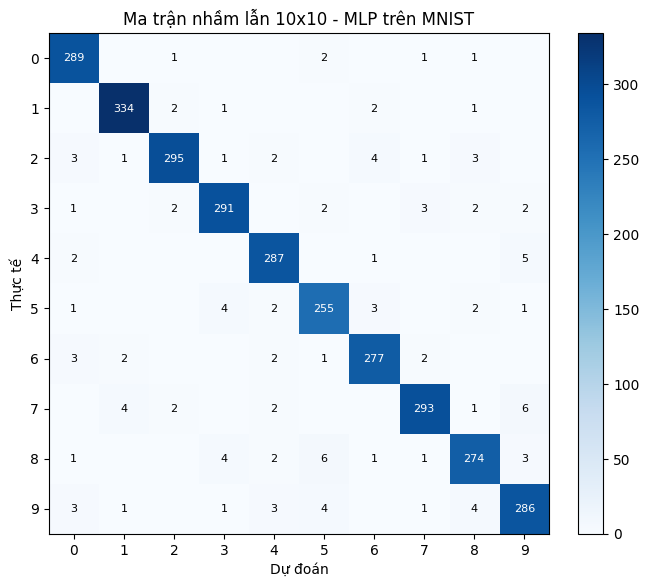

,thực tế,dự đoán,số lần
39,7,9,6
43,8,5,6
23,4,9,5
25,5,3,4
12,2,6,4
53,9,8,4
51,9,5,4
35,7,1,4
41,8,3,4
30,6,0,3


In [9]:
cm = confusion_matrix(yte, pred, labels=list(range(10)))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title("Ma trận nhầm lẫn 10x10 - MLP trên MNIST")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

pairs = [{"thực tế": i, "dự đoán": j, "số lần": int(cm[i, j])}
         for i in range(10) for j in range(10) if i != j and cm[i, j] > 0]
pairs_df = pd.DataFrame(pairs).sort_values("số lần", ascending=False)
pairs_df.head(10)

**Cách dùng trong nghiệp vụ:** nếu một cặp số cụ thể (ví dụ 4↔9)
chiếm phần lớn lỗi, ngân hàng có thể thiết kế thêm bước kiểm tra chéo riêng
cho cặp đó (ví dụ đối chiếu với số tiền bằng chữ trên séc) thay vì coi mọi
lỗi là như nhau.

## 11. 20 ảnh bị dự đoán SAI

Nhìn trực tiếp vào các mẫu sai để trả lời câu hỏi: **con người có đọc được
những ảnh này không?** Nếu có — model còn chỗ để cải thiện. Nếu không (nét
chữ thực sự mơ hồ) — đó là giới hạn của chính dữ liệu, không phải của model,
và củng cố lý do cần cơ chế human-in-the-loop ở bước 12.

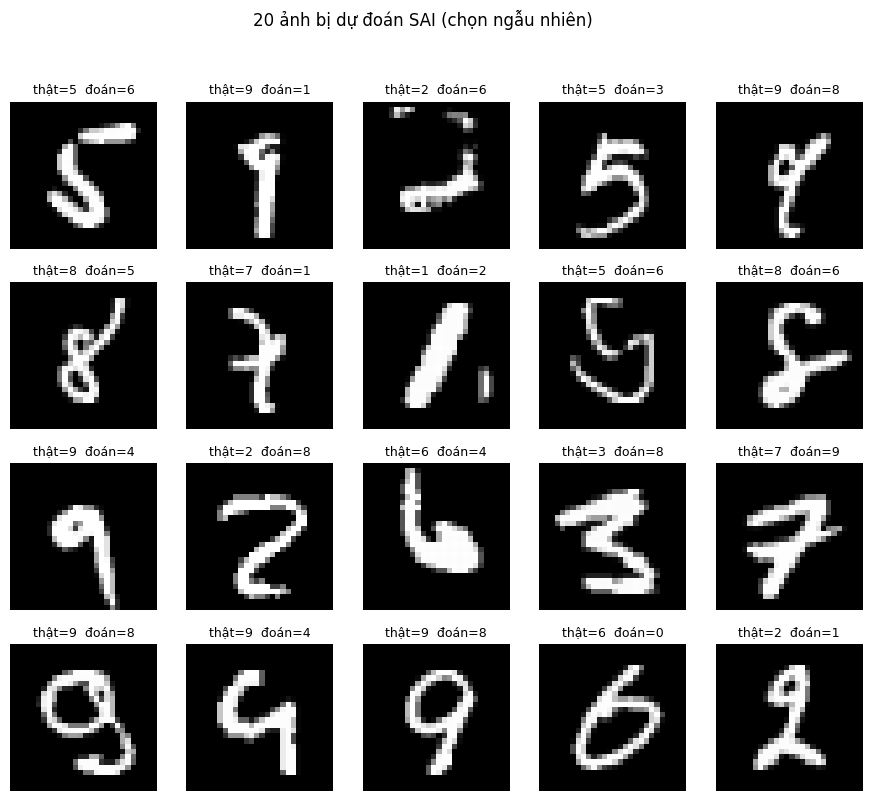

Số mẫu sai trên tập test: 119 / 3000 (3.97%)


In [10]:
wrong_idx = np.where(pred != yte)[0]
rng = np.random.RandomState(RANDOM_STATE)
show_idx = rng.choice(wrong_idx, size=min(20, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for ax, idx in zip(axes.ravel(), show_idx):
    ax.imshow(Xte[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"thật={yte[idx]}  đoán={pred[idx]}", fontsize=9)
    ax.axis("off")
fig.suptitle("20 ảnh bị dự đoán SAI (chọn ngẫu nhiên)")
plt.show()

print(f"Số mẫu sai trên tập test: {len(wrong_idx)} / {len(yte)} ({len(wrong_idx) / len(yte):.2%})")

## 12. ⭐ Cơ chế human-in-the-loop — ràng buộc bắt buộc trong nghiệp vụ tài chính

Sai 1 chữ số trong số tiền là **sai tiền thật**, nên model không chỉ trả về
nhãn dự đoán mà còn phải trả về **độ tin cậy** (`predict_proba().max()`).
Với mỗi ngưỡng tin cậy, ta đo: bao nhiêu % ca được **tự động** xử lý, và
trong số đó accuracy thực tế là bao nhiêu (để kiểm tra ngưỡng có "đáng tin"
như tên gọi hay không).

In [11]:
proba = final_pipe.predict_proba(Xte)
pred_from_proba = proba.argmax(axis=1)
confidence = proba.max(axis=1)

hitl_rows = []
for threshold in [0.90, 0.95, 0.99, 0.999]:
    auto_mask = confidence >= threshold
    n_auto = int(auto_mask.sum())
    pct_auto = n_auto / len(yte)
    acc_auto = accuracy_score(yte[auto_mask], pred_from_proba[auto_mask]) if n_auto else float("nan")
    hitl_rows.append({"ngưỡng tin cậy": threshold, "% tự động": pct_auto,
                       "% chuyển người": 1 - pct_auto, "accuracy (phần tự động)": acc_auto})
    print(f"ngưỡng={threshold:.3f}  tự động={pct_auto:.2%}  chuyển người={1 - pct_auto:.2%}  "
          f"accuracy(tự động)={acc_auto:.4%}")

pd.DataFrame(hitl_rows)

ngưỡng=0.900  tự động=92.43%  chuyển người=7.57%  accuracy(tự động)=98.6296%
ngưỡng=0.950  tự động=89.17%  chuyển người=10.83%  accuracy(tự động)=99.1776%
ngưỡng=0.990  tự động=80.47%  chuyển người=19.53%  accuracy(tự động)=99.7929%
ngưỡng=0.999  tự động=61.93%  chuyển người=38.07%  accuracy(tự động)=99.8924%


,ngưỡng tin cậy,% tự động,% chuyển người,accuracy (phần tự động)
0,0.9000,0.9243,0.0757,0.9863
1,0.9500,0.8917,0.1083,0.9918
2,0.9900,0.8047,0.1953,0.9979
3,0.9990,0.6193,0.3807,0.9989


**Đọc bảng trên:** ở ngưỡng 99%, accuracy trên phần được tự động
duyệt phải xấp xỉ (hoặc cao hơn) 99% — nếu đúng như vậy, ngưỡng "đáng tin
cậy 99%" thực sự phản ánh đúng chất lượng dự đoán, chứ không phải một con số
tuỳ tiện. Phần trăm còn lại (chuyển người) chính là khối lượng công việc
nhân viên vẫn cần xử lý thủ công — đây là con số ngân hàng dùng để tính toán
nhân sự cần thiết khi triển khai hệ thống.

## 13. So sánh định tính với CNN (TT-26)

MLP xử lý ảnh bằng cách **trải phẳng** ma trận 28×28 thành vector 784 chiều
— vì vậy nó **mất hoàn toàn cấu trúc không gian 2D** của ảnh: pixel ở góc
trên-trái và pixel cạnh nó bị đối xử như hai đặc trưng độc lập, không liên
quan, dù trong ảnh thật chúng liền kề nhau. Hệ quả trực tiếp: MLP **không
bất biến với dịch chuyển/xoay nhẹ** — cùng một chữ số dịch vài pixel có thể
tạo ra vector input rất khác.

**CNN** (Convolutional Neural Network, TT-26) dùng phép tích chập trượt trên
toàn ảnh, chia sẻ trọng số qua các vị trí — vừa giữ được cấu trúc không gian,
vừa bất biến cục bộ với dịch chuyển nhỏ. Đây là lý do CNN thường đạt
**>99%** trên MNIST, cao hơn rõ rệt so với MLP (~97–98%) dù cùng là mạng
nơ-ron truyền thẳng có backpropagation. Notebook này **không huấn luyện lại
CNN** (thuộc phạm vi TT-26) — đây là so sánh định tính dựa trên đặc điểm
kiến trúc, không phải số đo thực nghiệm trực tiếp trong bài này.

## Tổng kết

| Hạng mục | Kết quả |
| :--- | :--- |
| Baseline Logistic Regression | xem mục 3 |
| Không chuẩn hoá vs có chuẩn hoá | xem bảng mục 4-5 |
| So sánh 4 kiến trúc + số tham số | xem bảng + đồ thị mục 6-7 |
| So sánh 3 activation (vanishing gradient) | xem bảng + đồ thị mục 8 |
| So sánh 3 learning_rate_init | xem bảng + đồ thị mục 9 |
| Accuracy model cuối trên test | xem mục "Huấn luyện model CUỐI CÙNG" |
| Ma trận nhầm lẫn 10×10 + cặp hay nhầm | xem mục 10 |
| ⭐ Bảng human-in-the-loop (ngưỡng 99%) | xem bảng mục 12 |

**Hạn chế cần nêu rõ:**
1. Notebook dùng mẫu 12.000/3.000 (không phải toàn bộ 60.000/10.000) để
   giới hạn thời gian chạy — accuracy tuyệt đối vì vậy có thể thấp hơn khi
   chạy full data (đặt `TRAIN_SAMPLE = None` trong `src/train.py` để chạy
   đầy đủ).
2. MLP làm **mất cấu trúc không gian** của ảnh do trải phẳng thành vector —
   xem so sánh với CNN ở mục 13.
3. Ngưỡng tin cậy human-in-the-loop được hiệu chỉnh trên tập test hiện tại;
   khi triển khai thực tế cần theo dõi lại trên dữ liệu sản xuất (phân bố
   nét chữ, loại giấy, máy quét... có thể khác).

Số liệu đầy đủ (CSV các bảng so sánh, ảnh PNG, tóm tắt JSON) được lưu lại
trong thư mục `../reports/` bởi `src/train.py` — notebook này dùng để
**giải thích lý do và cách đọc** từng bước, còn script dùng để tái lập kết
quả tự động.